**RANDOM IMPUTATION**
Choses random number from the columns. Random doesn't mean complete random. It basically means the random values among the given data. This preserves normality of the data and varience

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [3]:
df = pd.read_csv('../../../EDA/data/train.csv', usecols=['Age', 'Fare', 'Survived'])

In [4]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [5]:
df.isnull().mean() * 100

Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

In [6]:
X = df.drop('Survived', axis=1)
y = df['Survived']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
X_train

,Age,Fare
331,45.5,28.5000
733,23.0,13.0000
382,32.0,7.9250
704,26.0,7.8542
813,6.0,31.2750
...,...,...
106,21.0,7.6500
270,NaN,31.0000
860,41.0,14.1083
435,14.0,120.0000


In [9]:
X_train['Age_imputed'] = X_train['Age']
X_test['Age_imputed'] = X_test['Age']

In [10]:
X_train.tail()

,Age,Fare,Age_imputed
106,21.0,7.6500,21.0
270,NaN,31.0000,NaN
860,41.0,14.1083,41.0
435,14.0,120.0000,14.0
102,21.0,77.2875,21.0


In [11]:
X_train['Age_imputed'][X_train['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values


In [12]:
X_test['Age_imputed'][X_test['Age_imputed'].isnull()] = X_test['Age'].dropna().sample(X_test['Age'].isnull().sum()).values

In [13]:
X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values

array([62. , 16. , 15. , 18. , 26. , 42. , 17. , 28. , 22. , 18. , 33. ,
        2. , 30. , 46. , 19. ,  8. , 35. , 23. , 45. , 29. , 30. , 58. ,
       18. , 33. , 24. , 24. , 31. , 38. , 29. , 28. , 18. , 25. , 32. ,
       31. , 18. , 21. ,  2. , 29. , 37. , 64. , 31. , 25. , 30. , 41. ,
       33. , 24. , 40. , 17. , 51. , 22. ,  5. , 30. , 30. , 19. , 41. ,
       35. , 16. , 16. , 22. , 29. , 24. , 32. , 31. , 21. , 43. , 20. ,
       21. ,  4. , 25. , 14. ,  6. , 40. , 38. , 28. , 48. , 27. , 22. ,
       31. , 19. , 28. , 28. , 16. , 33. , 34. , 32. , 42. , 24. , 33. ,
       27. , 19. ,  2. , 31. , 31. , 18. , 42. , 25. , 15. , 24. , 30. ,
       22. , 59. , 22. , 40. , 19. , 54. , 39. ,  9. , 11. , 24. , 21. ,
       26. , 20. , 28.5, 45. , 21. , 36. , 44. , 28. , 48. , 30. , 24. ,
       21. , 14. , 25. , 42. , 51. , 36. ,  9. , 55. , 47. , 27. , 26. ,
       54. , 25. , 65. , 61. ,  8. , 35. , 27. , 27. ])

In [14]:
X_train.isnull().sum()

Age            140
Fare             0
Age_imputed      0
dtype: int64

C:\Users\ASUS\AppData\Local\Temp\ipykernel_11812\3773879143.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=False`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(X_train['Age'], label='Original Age', shade=False)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_11812\3773879143.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=False`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(X_train['Age_imputed'], label='Imputed Age', shade=False, color='red')


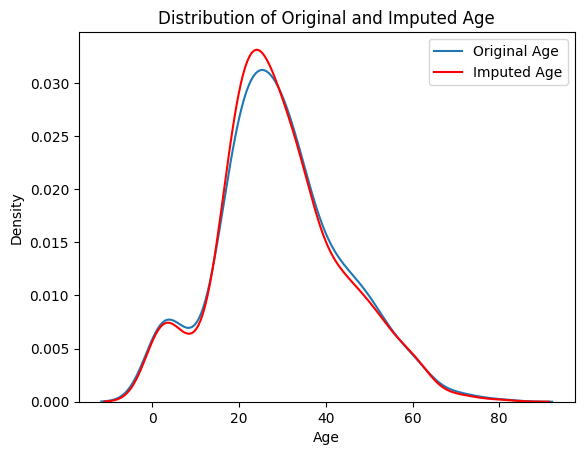

In [15]:
sns.kdeplot(X_train['Age'], label='Original Age', shade=False)
sns.kdeplot(X_train['Age_imputed'], label='Imputed Age', shade=False, color='red')
plt.legend()
plt.title('Distribution of Original and Imputed Age')
plt.show()

In [16]:
print("Original Age Mean:", X_train['Age'].var())
print("Imputed Age Mean:", X_train['Age_imputed'].var())

Original Age Mean: 210.2517072477435
Imputed Age Mean: 201.9667408453041


In [17]:
X_train.cov()

,Age,Fare,Age_imputed
Age,210.251707,71.580633,210.251707
Fare,71.580633,2700.831981,53.193383
Age_imputed,210.251707,53.193383,201.966741


<Axes: >

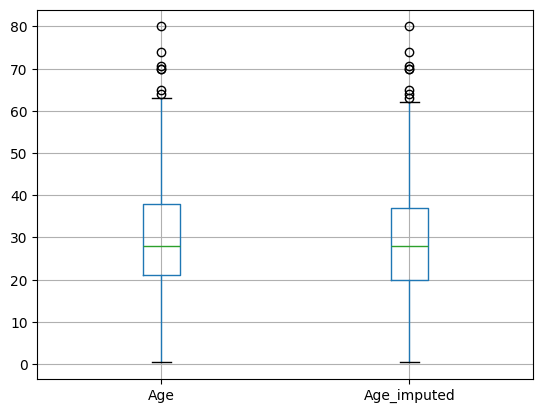

In [18]:
X_train.drop('Fare', axis=1).boxplot()

In [19]:
#For categorical
data = pd.read_csv('../../../EDA/data/house.csv', usecols=['GarageQual', 'FireplaceQu', 'SalePrice'])

In [20]:
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [21]:
data.isnull().mean() * 100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [31]:
X = data
y = data['SalePrice']

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [33]:
X_train['GarageQual_imputed'] = X_train['GarageQual']
X_test['GarageQual_imputed'] = X_test['GarageQual']

X_train['FireplaceQu_imputed'] = X_train['FireplaceQu']
X_test['FireplaceQu_imputed'] = X_test['FireplaceQu']

In [34]:
X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum()).values

C:\Users\ASUS\AppData\Local\Temp\ipykernel_11812\2263490880.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum()).values


In [35]:
X_test['GarageQual_imputed'][X_test['GarageQual_imputed'].isnull()] = X_test['GarageQual'].dropna().sample(X_test['GarageQual'].isnull().sum()).values

X_train['FireplaceQu_imputed'][X_train['FireplaceQu_imputed'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_train['FireplaceQu'].isnull().sum()).values
X_test['FireplaceQu_imputed'][X_test['FireplaceQu_imputed'].isnull()] = X_test['FireplaceQu'].dropna().sample(X_test['FireplaceQu'].isnull().sum()).values

C:\Users\ASUS\AppData\Local\Temp\ipykernel_11812\2199404913.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test['GarageQual_imputed'][X_test['GarageQual_imputed'].isnull()] = X_test['GarageQual'].dropna().sample(X_test['GarageQual'].isnull().sum()).values
C:\Users\ASUS\AppData\Local\Temp\ipykernel_11812\2199404913.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train['FireplaceQu_imputed'][X_train['FireplaceQu_imputed'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_train['FireplaceQu'].isnull().sum()).values
C:\Users\ASUS\AppData\Local\Temp\ipykernel_11812\2199404913.py:4: SettingWithCopyWarning: 
A

In [36]:
temp = pd.concat(
        [
            X_train['GarageQual'].value_counts() / len(X_train['GarageQual'].dropna()),
            X_train['GarageQual_imputed'].value_counts() / len(X_train)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

In [37]:
temp

,original,imputed
TA,0.951087,0.950342
Fa,0.032609,0.033390
Gd,0.011775,0.011130
Ex,0.002717,0.003425
Po,0.001812,0.001712


In [29]:
temp = pd.concat(
        [
            X_train['FireplaceQu'].value_counts() / len(X_train['FireplaceQu'].dropna()),
            X_train['FireplaceQu_imputed'].value_counts() / len(df)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

temp

,original,imputed
Gd,0.491143,0.638608
TA,0.405797,0.536476
Fa,0.043478,0.059484
Ex,0.033816,0.042649
Po,0.025765,0.033670


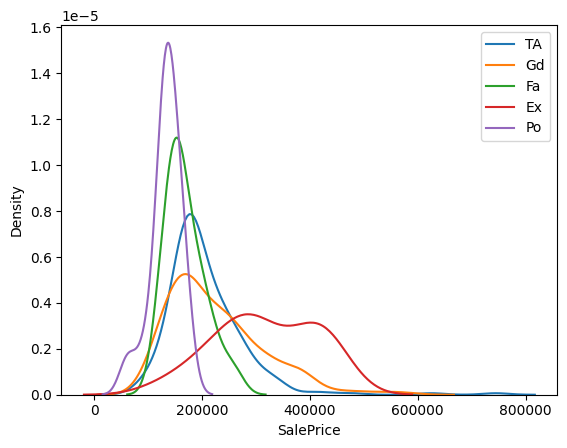

In [43]:
for category in X_train['FireplaceQu'].dropna().unique():
    sns.kdeplot(X_train[X_train['FireplaceQu'] == category]['SalePrice'],label=category)

plt.legend()
plt.show()

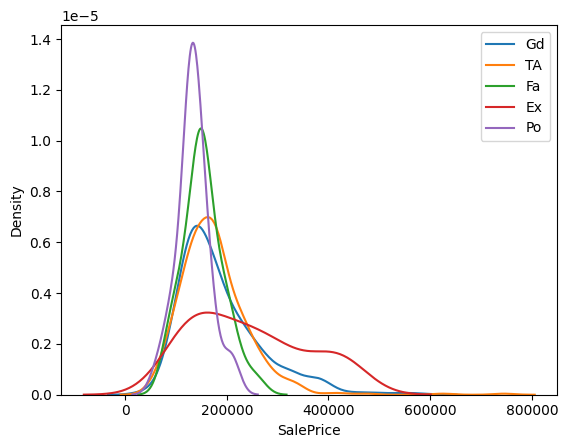

In [42]:
for category in X_train['FireplaceQu_imputed'].dropna().unique():
    sns.kdeplot(X_train[X_train['FireplaceQu_imputed'] == category]['SalePrice'],label=category)
plt.legend()
plt.show()